<a href="https://colab.research.google.com/github/thomashooks53/undergrad_ml_assignments/blob/main/03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Linear Models

##**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

    - A model is “linear” if it is linear in its coefficients, not in the input variables. That means each coefficient multiplies a term and they are added together, with no coefficients multiplied by each other or inside nonlinear functions.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

    - The coefficient represents the difference in the predicted outcome compared to the reference category, holding all other variables constant. The intercept corresponds to the baseline group, so the dummy variable coefficient shows how much you add or subtract from that baseline when the dummy equals 1.

3. Can linear regression be used for classification? Explain why, or why not.

    - Yes, but it doesn't work very well. Linear regression can produce predictions outside the range [0,1], which don't make sense as probabilities. It also assumes constant variance and normally distributed errors, which isn't usuallt the case in classification problems. That's why methods like logistic regression are preferred.

4. What are signs that your linear model is over-fitting?

    - Overfitting is indicated when the model performs very well on training data but poorly on test data. Other signs include very large coefficients, high sensitivity to small changes in data, and capturing noise rather than true patterns.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

    - Multicollinearity occurs when one predictor can be closely explained by other predictors, making it hard to isolate its effect. In a two-stage idea:
      - First, regress the problematic variable on the others to see how predictable it is.
      - If it is highly predictable, then in the second stage, its unique variation (what’s left after removing overlap) is very small, so its coefficient becomes unstable and hard to estimate reliably.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

    - You can include transformed or engineered features such as polynomial terms (e.g., $x$<sup>2</sup>), interaction terms (e.g., $x$<sub>1</sub>$x$<sub>2</sub>), or functions like logs or exponentials. Even though the relationship in $x$ is nonlinear, the model remains linear in coefficients.

7. What is the interpretation of the slope coefficient in a linear regression?

    - The slope coefficient represents the expected change in the response variable $y$ for a one-unit increase in the predictor, holding all other variables constant.

8. Compare the train/test split and $k$-fold cross validation.

    - Train/test split: Simple and fast; data is split once into training and testing sets. However, results can depend heavily on how the split is done.
    - $k$-fold cross-validation: Data is split into $k$ parts, and the model is trained/tested multiple times. This gives a more reliable estimate of performance but is more computationally expensive.

9. How is the $k$ in $k$-fold cross validation typically selected?

    - Choosing $k$ is a trade-off between time and accuracy. If $k$ is too small, you aren't using enough data to get a good training signal. If $k$ is too large, the process takes too long and can lead to high variance. Most people use $k=5$ or $k=10$. These values provide a great balance, giving a stable estimate of the model's accuracy without requiring an excessive amount of computing power.


### **Run:** get_data.py

In [3]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

##**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

##Question 2 - Part 1

In [4]:
import pandas as pd
import numpy as np

airbnb = pd.read_csv("/content/data/Q1_clean.csv")
display(airbnb.head())

print(airbnb.columns.tolist())

airbnb.columns = airbnb.columns.str.strip()

avg_airbnb = airbnb.groupby("Neighbourhood").agg({
    "Price": "mean",
    "Review Scores Rating": "mean"
}).reset_index()

avg_airbnb = avg_airbnb.rename(columns={
    "Price": "AvgPrice",
    "Review Scores Rating": "AvgRating"
})

display(avg_airbnb)

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type', 'Room Type']


,Neighbourhood,AvgPrice,AvgRating
0,Bronx,75.276498,91.654378
1,Brooklyn,127.747378,92.363497
2,Manhattan,183.664286,91.801496
3,Queens,96.857233,91.549057
4,Staten Island,146.166667,90.843750


- Initially, my code wasn't working, saying that "Neighbourhood" wasn't in the dataset. Upon looking at the column names, it was actually "Neighbourhood " with a space. To solve this, the column name was stripped of the space, and then the code could be continued.

- Grouping by Neighbourhood, the average prices and ratings were found. On average, Manhattan is by far the most expensive, while the Bronx is the cheapest. Staten Island has the lowest ratings on average, and Brooklyn has the highest average ratings.

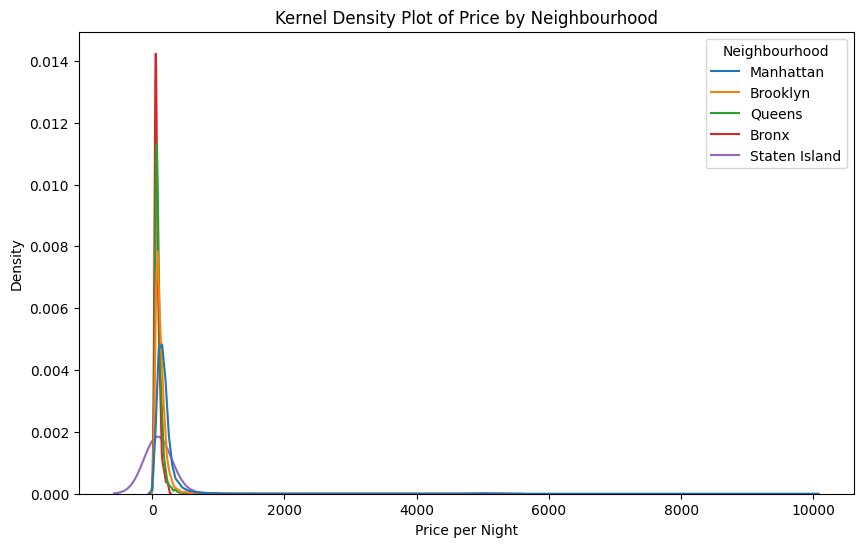

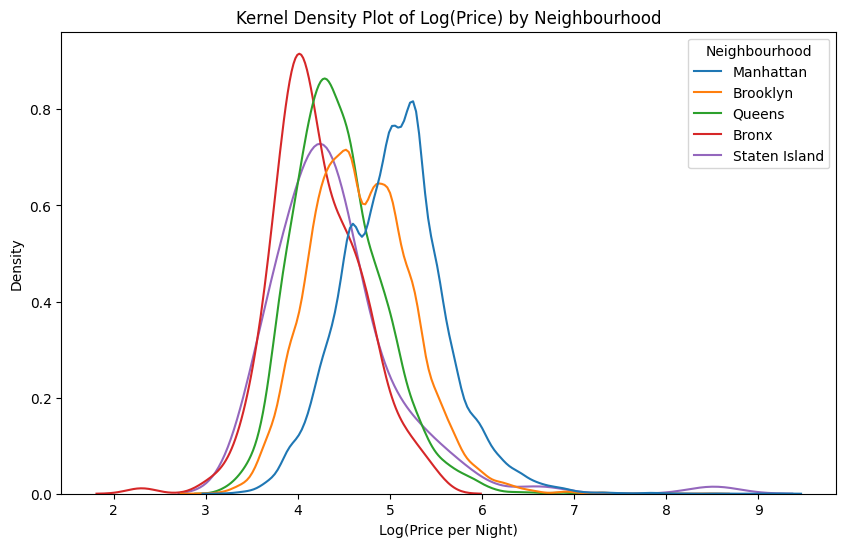

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#Prices
plt.figure(figsize=(10,6))
sns.kdeplot(
    data=airbnb,
    x="Price",
    hue="Neighbourhood",
    common_norm=False
)
plt.title("Kernel Density Plot of Price by Neighbourhood")
plt.xlabel("Price per Night")
plt.ylabel("Density")
plt.show()

#Log Prices
airbnb["log_price"] = np.log(airbnb["Price"])

plt.figure(figsize=(10,6))
sns.kdeplot(
    data=airbnb,
    x="log_price",
    hue="Neighbourhood",
    common_norm=False
)
plt.title("Kernel Density Plot of Log(Price) by Neighbourhood")
plt.xlabel("Log(Price per Night)")
plt.ylabel("Density")
plt.show()

The outliers in the regular kernel density plot make it difficult to extract any real information, so I wanted to redo it with outliers excluded.

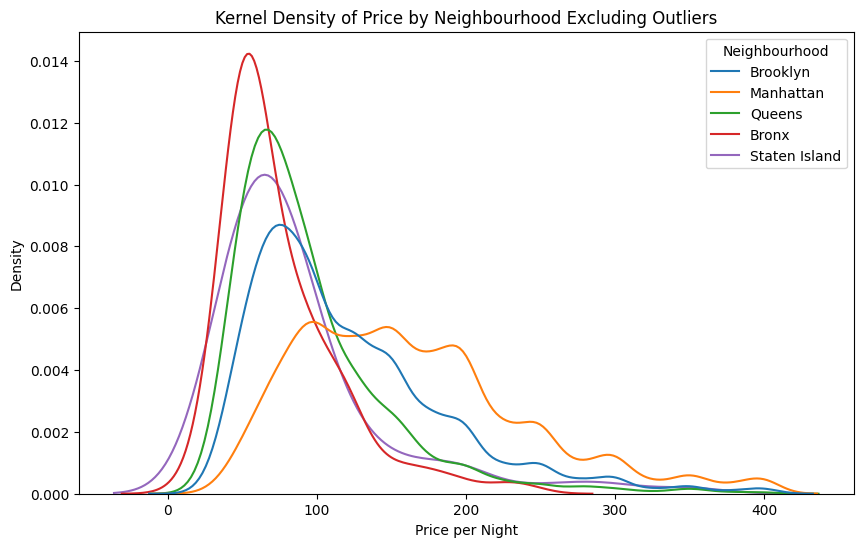

In [6]:
price_limit = airbnb["Price"].quantile(0.97)

plt.figure(figsize=(10,6))
sns.kdeplot(
    data=airbnb[airbnb["Price"] <= price_limit],
    x="Price",
    hue="Neighbourhood",
    common_norm=False
)
plt.title("Kernel Density of Price by Neighbourhood Excluding Outliers")
plt.xlabel("Price per Night")
plt.ylabel("Density")
plt.show()

##Question 2 - Part 2

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

X_nb = pd.get_dummies(airbnb['Neighbourhood'], drop_first=True)
y = airbnb['Price']

model_nb = LinearRegression().fit(X_nb, y)
print(f"Intercept: {model_nb.intercept_:.2f}")
print(pd.Series(model_nb.coef_, index=X_nb.columns))

Intercept: 75.28
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64


I chose to drop the first category, yielding the above results. This model takes the mean fom the dropped category (Bronx), and then computes the differences between the other boroughs. Adding the differences to the intercept, the following data is obtained.

 - Bronx: 75.28
 - Brooklyn: 75.28 + 52.47 = 127.75
 - Manhattan: 75.28 + 108.39 = 183.67
 - Queens: 75.28 + 21.58 = 96.86
 - Staten Island: 75.28 + 70.89 = 146.17

This matches table 1 exactly after the adjustment, which makes sense as this model is simply calculating the differences from the reference.

##Question 2 - Part 3

In [8]:
y = airbnb['Price']
X_score = airbnb[['Review Scores Rating']]
model_score = LinearRegression().fit(X_score, y)
print(f"Intercept: {model_score.intercept_:.2f}")
print(f"Slope: {model_score.coef_[0]:.2f}")

Intercept: 60.88
Slope: 1.02


This linear model is comparing the relationship between price and review score. Since $y$ is price and $x$ is the review score, the equation is Price = 60.88 + 1.02(Review Score). Essentially, a review score of 0 would correlate to a price of 60.88.

##Question 2 - Part 4

In [13]:
X_multi = pd.concat([X_nb, airbnb[['Review Scores Rating']]], axis=1)
model_multi = LinearRegression().fit(X_multi, y)
print(f"Rating Slope (Controlling for Location): {model_multi.coef_[-1]:.2f}")

model_4 = LinearRegression().fit(X_multi, airbnb['Price'])

print(f"\nNew Intercept (Baseline at 0 Rating): {model_4.intercept_:.2f}")

new_coeffs = pd.Series(model_4.coef_, index=X_multi.columns)
print("\nNew Borough Coefficients (Difference at 0 Rating):")
print(new_coeffs.drop('Review Scores Rating'))

Rating Slope (Controlling for Location): 1.08

New Intercept (Baseline at 0 Rating): -23.81

New Borough Coefficients (Difference at 0 Rating):
Brooklyn          51.704240
Manhattan        108.228737
Queens            21.694600
Staten Island     71.766552
dtype: float64


This new regression changes the slope by only comparing prices and ratings within a neighbourhood. This helps give a more accurate comparison between review score and price, because it is no longer affected by confusing inter-neighbourhood comparisons. For example, a very expensive Manhattan apartment would be compared to a cheap but higher rated apartment from the Bronx. This confuses the model, leading to a low slope which implies very little correlation between the two variables. However, within one neighbourhood, there isn't the wild variance in price, allowing actual correlation to be found, raising the slope to 1.08.

The Borough coefficients are also affected, as the boroughs are now compared to the refererences at the same review score. Initially, the model simply compared the means of all prices, but comparing prices at the same review score gives a more accurate analysis in comparing prices of similar quality properties. This leads to the resulting data above, with -23.81 being the price of a Bronx property with a rating of 0 (Negative because no review scores even come close to 0), and the coefficients being the difference in price also with a rating of 0. This yields the following changes:

Difference in coefficients:

 - Brooklyn: 52.47 - 51.70 = 0.77
 - Manhattan: 108.39 - 108.23 = 0.16
 - Queens: 21.58 - 21.69 = -0.11
 - Staten Island: 70.89 - 71.77 = -0.88


This means that, while Manhattan was $108.39$ dollars more expensive than the Bronx on average, it is only $108.23$ dollars more expensive at the same review score.

Looking at the trends, it seems that both Brooklyn and Manhattan are slightly higher rated in general than the Bronx, and Queens and Staten Island are slightly lower rated.

##Question 2 - Part 5

In [16]:
boroughs = airbnb['Neighbourhood'].unique()

X_puzzle = pd.DataFrame()
for b in boroughs:
    X_puzzle[f'{b}'] = (airbnb['Neighbourhood'] == b).astype(int) * airbnb['Review Scores Rating']

X_puzzle['Constant'] = 1

model_puzzle = LinearRegression(fit_intercept=False).fit(X_puzzle, airbnb['Price'])

puzzle_results = pd.Series(model_puzzle.coef_, index=X_puzzle.columns)
print("The Puzzle: Separate Slopes per Neighborhood")
print(puzzle_results.to_string())

The Puzzle: Separate Slopes per Neighborhood
Manhattan         1.399376
Brooklyn          0.790947
Queens            0.456451
Bronx             0.222718
Staten Island     0.682444
Constant         55.118254


The constant here represents the baseline $0$ review score across all of New York. From this baseline, the slope represents how much the price of the airbnb rises per an increase in review score of 1. For example, a Manhattan apartment with a review score of 1 raises to $56.51$ dollars, whereas an airbnb in the Bronx only raises to $55.33$ dollars. Essentially, the greater the slope, the more money someone will pay for increased quality (review score). Manhattan has the highest premium for high quality, while people are less willing for play for premium airbnbs in the Bronx.

The major flaw with this model is it forces all of the boroughs into the same price for a review score of $0$. In reality, Manhattan would likely also be more expensive than the Bronx at a review score of $0$.

In summary, the slopes are not the same, with each borough charging vastly different amounts based on the review score.

##Question 2 - Part 6

To preface, this is part 6, and it is asking for the models in parts 4-6. I am slightly confused in what models this then means, so I am testing for the four models from parts 2-5.

In [19]:
def get_rmse(X, y_data):
    mse_scores = cross_val_score(LinearRegression(), X, y_data, cv=10, scoring='neg_mean_squared_error')
    return np.sqrt(-mse_scores.mean())

print("10-Fold Cross Validation (RMSE):")
print(f"Model 2 (Location Only):    ${get_rmse(X_nb, y):.2f}")
print(f"Model 3 (Rating Only):      ${get_rmse(X_score, y):.2f}")
print(f"Model 4 (Parallel Slopes):  ${get_rmse(X_multi, y):.2f}")
print(f"Model 5 (The Puzzle):       ${get_rmse(X_puzzle, y):.2f}")

10-Fold Cross Validation (RMSE):
Model 2 (Location Only):    $145.54
Model 3 (Rating Only):      $148.64
Model 4 (Parallel Slopes):  $145.24
Model 5 (The Puzzle):       $145.15


The $10$-fold cross-validation reveals that Model 5 is the most accurate predictor of price, achieving the lowest RMSE of $145.15$ dollars.

While Model $2$ provides a strong baseline, adding Review Scores in Model $4$ and Model $5$ consistently reduced the error. The fact that Model $5$ outperformed Model $4$ suggests that the value of a higher review score is not uniform across New York, rather, the market places a different premium on quality depending on the neighborhood. However, the narrow margin between these models ($0.09) indicates that while quality matters, location remains the primary driver of price variance in this dataset.

Model $3$ is the least accurate because it attempts to predict price based on quality alone, ignoring the massive price variance caused by neighbourhood. The fact that Model $3$ has a higher RMSE than Model $2$ ($148.64$ vs $145.54$) proves that in this market, the  location of a property is a far more powerful predictor of price than the guest's satisfaction rating.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


##Question 3 - Part 1

##Question 3 - Part 2

##Question 3 - Part 3

##Question 3 - Part 4

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


##Question 4 - Part 1

##Question 4 - Part 2

##Question 4 - Part 3

##Question 4 - Part 4

##Question 4 - Part 5

##Question 4 - Part 6